# 01 — Data Exploration

Goals:
- Verify dataset splits and class balance (train/val/test)
- Inspect processed audio assets and durations
- Visualize example waveform and log-mel spectrograms

This notebook follows the project structure and objectives defined in the Code Plan.

In [2]:
# Imports
import os
import sys
import json
import yaml
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
try:
    import librosa
    import librosa.display
except Exception as e:
    print("librosa import warning:", e)

sns.set_context("talk")
sns.set_style("whitegrid")

## Paths and configuration

Detect project root regardless of where the notebook is launched; load config/config.yaml; derive data/splits and data/processed paths.

In [3]:
def detect_project_root():
    cwd = Path.cwd()
    # If we're inside notebooks/, use its parent as project root
    if (cwd.name == 'notebooks') or (cwd / '01_data_exploration.ipynb').exists():
        return cwd.parent
    # If the expected folders exist here, accept cwd
    expected = ['config', 'data', 'scripts', 'notebooks']
    if all((cwd / d).exists() for d in expected):
        return cwd
    # Fallback: walk up a couple levels
    for p in [cwd.parent, cwd.parent.parent]:
        if all((p / d).exists() for d in expected):
            return p
    return cwd

PROJECT_ROOT = detect_project_root()
CONFIG_PATH = PROJECT_ROOT / 'config' / 'config.yaml'
print('Project root:', PROJECT_ROOT)
print('Config path :', CONFIG_PATH)

with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

# Support either top-level 'config' (preferred) or 'data' for robustness
data_cfg = cfg.get('config', cfg.get('data', {}))
classes = data_cfg.get('classes', [])
raw_dir = PROJECT_ROOT / data_cfg.get('raw_dir', 'data/raw')
processed_dir = PROJECT_ROOT / data_cfg.get('processed_dir', 'data/processed')
splits_dir = PROJECT_ROOT / 'data' / 'splits'
plots_dir = PROJECT_ROOT / 'results' / 'plots'
logs_dir = PROJECT_ROOT / 'results' / 'logs'

plots_dir.mkdir(parents=True, exist_ok=True)
logs_dir.mkdir(parents=True, exist_ok=True)

print('Classes      :', classes)
print('Raw dir      :', raw_dir)
print('Processed dir:', processed_dir)
print('Splits dir   :', splits_dir)
print('Plots dir    :', plots_dir)
print('Logs dir     :', logs_dir)

Project root: /Users/harryirving/Development/projects/ai-ml/BikeAIv3
Config path : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/config/config.yaml
Classes      : ['angle_grinder', 'background_noise', 'power_tools']
Raw dir      : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw
Processed dir: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/processed
Splits dir   : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/splits
Plots dir    : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/plots
Logs dir     : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/logs


## Load manifests (train/val/test)

Manifests created by scripts/01_prepare_data.py are simple CSV lines of "path,label".

In [4]:
def read_manifest(path: Path):
    rows = []
    if not path.exists():
        return pd.DataFrame(columns=['path', 'label'])
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rel, label = line.split(',', 1)
            abs_path = (PROJECT_ROOT / rel).resolve()
            rows.append({'path': abs_path.as_posix(), 'label': label})
    return pd.DataFrame(rows)

train_df = read_manifest(splits_dir / 'train.txt')
val_df   = read_manifest(splits_dir / 'val.txt')
test_df  = read_manifest(splits_dir / 'test.txt')

display(train_df.head(3))
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

,path,label
0,/Users/harryirving/Development/projects/ai-ml/...,angle_grinder
1,/Users/harryirving/Development/projects/ai-ml/...,angle_grinder
2,/Users/harryirving/Development/projects/ai-ml/...,angle_grinder


train: 979 val: 210 test: 212


## Class distribution

Plot per-split and overall class balance to check for imbalance and guide augmentation/training decisions.

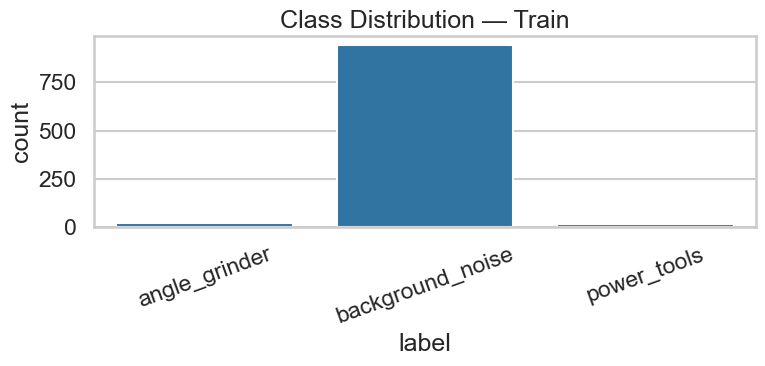

Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/plots/dist_train.png


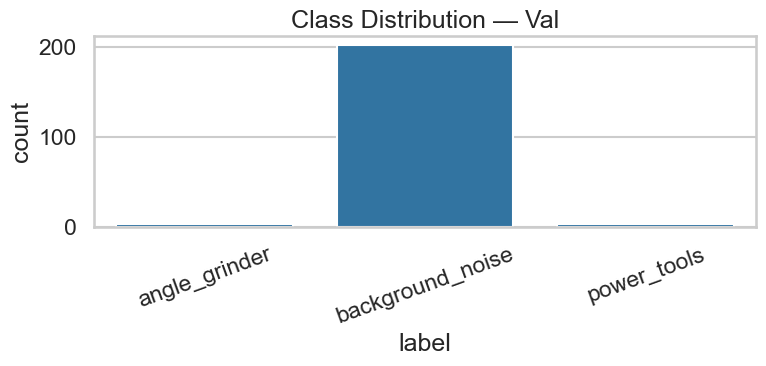

Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/plots/dist_val.png


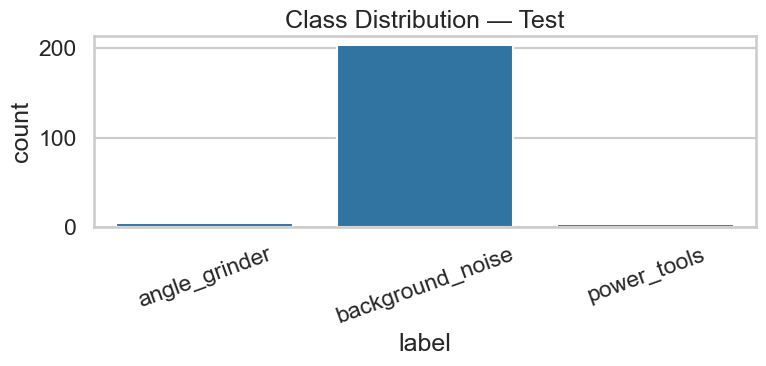

Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/plots/dist_test.png


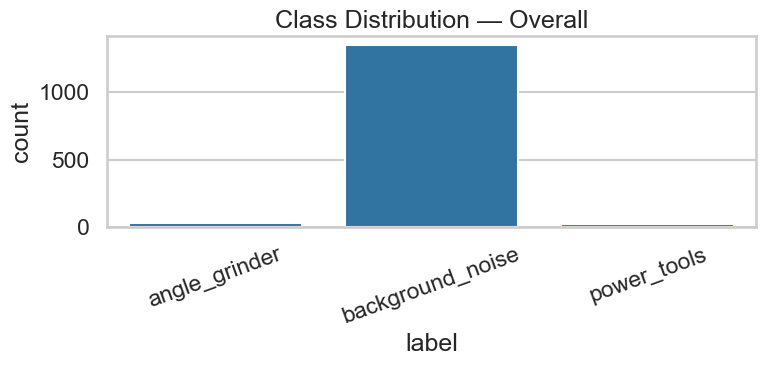

Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/plots/dist_overall.png


,label,train,val,test
0,background_noise,942,202,203
1,angle_grinder,21,4,5
2,power_tools,16,4,4


Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/logs/class_distribution_summary.csv


In [5]:
def plot_distribution(df, title, save_name):
    if df.empty:
        print(f"No data for {title}")
        return
    plt.figure(figsize=(8,4))
    order = classes if classes else None
    ax = sns.countplot(data=df, x='label', order=order)
    plt.title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    out = plots_dir / save_name
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)

plot_distribution(train_df, 'Class Distribution — Train', 'dist_train.png')
plot_distribution(val_df,   'Class Distribution — Val',   'dist_val.png')
plot_distribution(test_df,  'Class Distribution — Test',  'dist_test.png')

all_df = pd.concat([train_df.assign(split='train'),
                    val_df.assign(split='val'),
                    test_df.assign(split='test')], ignore_index=True)
plot_distribution(all_df, 'Class Distribution — Overall', 'dist_overall.png')

# Tabular summary
def split_summary(df, name):
    return df['label'].value_counts().rename_axis('label').reset_index(name=name)

summary = split_summary(train_df, 'train').merge(
          split_summary(val_df, 'val'), how='outer', on='label').merge(
          split_summary(test_df, 'test'), how='outer', on='label').fillna(0).astype({'train':int,'val':int,'test':int})
display(summary)

# Save CSV summary
summary_csv = logs_dir / 'class_distribution_summary.csv'
summary.to_csv(summary_csv, index=False)
print('Saved:', summary_csv)

## Processed audio availability

Check for processed/universal, processed/classical, processed/neural folders to tailor exploration steps accordingly.

In [6]:
universal_dir = processed_dir / 'universal'
classical_dir = processed_dir / 'classical'
neural_dir    = processed_dir / 'neural'
print('Universal dir:', universal_dir, 'exists:', universal_dir.exists())
print('Classical dir :', classical_dir,  'exists:', classical_dir.exists())
print('Neural dir    :', neural_dir,     'exists:', neural_dir.exists())

# Gather a small list of universal wavs if available
universal_wavs = []
if universal_dir.exists():
    universal_wavs = list(universal_dir.rglob('*.wav'))
    print('Found universal wavs:', len(universal_wavs))
else:
    print('Note: universal processed WAVs not found — run scripts/02_preprocess_all.py to generate.')

Universal dir: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/processed/universal exists: True
Classical dir : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/processed/classical exists: True
Neural dir    : /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/processed/neural exists: True
Found universal wavs: 13072


## Duration statistics (processed/universal)

Compute duration histogram and summary stats for 1s segments at target sample rate; gracefully skip if not present yet.

/Users/harryirving/Development/projects/ai-ml/BikeAIv3/venv/lib/python3.10/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Count: 2000 Mean: 1.0 Std: 0.0


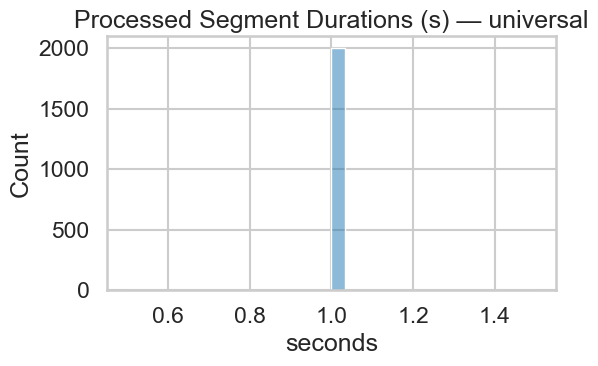

Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/plots/durations_universal.png


In [7]:
durations = []
sample = universal_wavs[:2000]  # cap for speed
for p in sample:
    try:
        # Prefer file-path based duration to avoid reading the whole file
        # Use 'path=' on newer librosa; 'filename=' on older
        try:
            d = librosa.get_duration(path=str(p))  # librosa >=0.10 uses 'path'
        except TypeError:
            d = librosa.get_duration(filename=str(p))  # librosa <=0.9.x fallback
        durations.append(d)
    except Exception:
        # Fallback: load minimally to estimate duration
        try:
            y, sr = librosa.load(str(p), sr=None, mono=True)
            durations.append(librosa.get_duration(y=y, sr=sr))
        except Exception:
            pass

if durations:
    durations = np.array(durations)
    print('Count:', len(durations), 'Mean:', durations.mean(), 'Std:', durations.std())
    plt.figure(figsize=(6,4))
    sns.histplot(durations, bins=30, kde=True)
    plt.title('Processed Segment Durations (s) — universal')
    plt.xlabel('seconds')
    plt.tight_layout()
    out = plots_dir / 'durations_universal.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)
else:
    print('No processed durations to plot yet.')


## Example waveform and log-mel spectrogram

Pick one file per class from manifests that exists in processed/universal set; fall back to raw if necessary (may show variable sample rates).

In [8]:
def pick_examples_by_class(df, classes, n_per_class=1):
    picks = {}
    for c in classes:
        sub = df[df['label'] == c]
        if not sub.empty:
            picks[c] = list(sub['path'].values)[:n_per_class]
    return picks

overall_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
examples = pick_examples_by_class(overall_df, classes, n_per_class=2)
examples

{'angle_grinder': ['/Users/harryirving/Development/projects/ai-ml/BikeAIv3/angle_grinder/angle-grinder-on-metal-66005.mp3',
  '/Users/harryirving/Development/projects/ai-ml/BikeAIv3/angle_grinder/659926__legand569__using-an-angle-grinderowi.wav'],
 'background_noise': ['/Users/harryirving/Development/projects/ai-ml/BikeAIv3/background_noise/chunk_1067.wav',
  '/Users/harryirving/Development/projects/ai-ml/BikeAIv3/background_noise/chunk_923.wav'],
 'power_tools': ['/Users/harryirving/Development/projects/ai-ml/BikeAIv3/power_tools/handheld-sander-with-flexible-shaft-grinding-aluminum-320668.mp3',
  '/Users/harryirving/Development/projects/ai-ml/BikeAIv3/power_tools/table-circular-saw-300506.mp3']}

In [9]:
def to_processed_candidate(path_str: str, processed_root: Path):
    """Attempt to map a raw path to corresponding processed/universal candidate by filename match."""
    p = Path(path_str)
    if processed_root.exists():
        hits = list(processed_root.rglob(p.stem + '.wav'))
        if hits:
            return hits[0]
    return Path(path_str)

def show_waveform_and_mel(path: Path, target_sr=16000, n_mels=40, n_fft=512, hop_length=160):
    try:
        y, sr = librosa.load(str(path), sr=target_sr, mono=True)
    except Exception as e:
        print('Failed to load', path, e)
        return
    fig, ax = plt.subplots(2, 1, figsize=(10,6))
    # Explicit color avoids Matplotlib 3.8+ prop_cycler access
    librosa.display.waveshow(y, sr=sr, ax=ax[0], color="C0")
    ax[0].set_title(f'Waveform: {path.name}')

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax[1])
    ax[1].set_title('Log-Mel Spectrogram (dB)')
    fig.colorbar(img, ax=ax[1], format="%+2.f dB")
    plt.tight_layout()
    plt.show()


# Try to display up to 1 example per class
for c, paths in examples.items():
    if not paths:
        continue
    candidate = to_processed_candidate(paths[0], universal_dir)
    print(f"Class: {c}  →  {candidate}")
    show_waveform_and_mel(candidate)

Class: angle_grinder  →  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/angle_grinder/angle-grinder-on-metal-66005.mp3
Failed to load /Users/harryirving/Development/projects/ai-ml/BikeAIv3/angle_grinder/angle-grinder-on-metal-66005.mp3 [Errno 2] No such file or directory: '/Users/harryirving/Development/projects/ai-ml/BikeAIv3/angle_grinder/angle-grinder-on-metal-66005.mp3'
Class: background_noise  →  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/background_noise/chunk_1067.wav
Failed to load /Users/harryirving/Development/projects/ai-ml/BikeAIv3/background_noise/chunk_1067.wav [Errno 2] No such file or directory: '/Users/harryirving/Development/projects/ai-ml/BikeAIv3/background_noise/chunk_1067.wav'
Class: power_tools  →  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/power_tools/handheld-sander-with-flexible-shaft-grinding-aluminum-320668.mp3
Failed to load /Users/harryirving/Development/projects/ai-ml/BikeAIv3/power_tools/handheld-sander-with-flexible-shaft

/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_11676/1020101820.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(path), sr=target_sr, mono=True)
/Users/harryirving/Development/projects/ai-ml/BikeAIv3/venv/lib/python3.10/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## Save EDA summary

Persist a lightweight JSON summary (class counts per split; basic processed availability).

In [10]:
eda = {
    'classes': classes,
    'counts': {
        'train': train_df['label'].value_counts().to_dict(),
        'val':   val_df['label'].value_counts().to_dict(),
        'test':  test_df['label'].value_counts().to_dict(),
    },
    'paths': {
        'raw_dir': str(raw_dir),
        'processed_dir': str(processed_dir),
        'splits_dir': str(splits_dir),
    },
    'processed_available': {
        'universal': (processed_dir / 'universal').exists(),
        'classical': (processed_dir / 'classical').exists(),
        'neural':    (processed_dir / 'neural').exists(),
    }
}
eda_path = logs_dir / 'eda_summary.json'
with open(eda_path, 'w') as f:
    json.dump(eda, f, indent=2)
print('Saved:', eda_path)

Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/logs/eda_summary.json
